In [1]:
import pandas as pd
import numpy as np 
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(f"D:\Web Scrapping\project\Wemedgood\Clean_FunctionData.xls")

In [3]:
df.head(10)

,Name,Ratings,Reviews,Type,Menu_price,Rooms,Pax_Min,Pax_Max,Destination,Amenities_+more
0,aurum conventions and resort sohna road gurgaon,5.0,62,hotel with banquet & lawn,2600.0,20.0,60,2000,gurgaon,6
1,le méridien new delhi,5.0,24,wedding destination\t,5500.0,358.0,25,1000,ncr,3
2,the leela palace new delhi,4.8,21,luxury city center hotel,6000.0,254.0,25,300,ncr,6
3,"radisson blu hotel, new delhi dwarka",5.0,40,5 star hotel,2800.0,240.0,35,800,ncr,4
4,the grand new delhi,4.6,19,5 star hotel,4000.0,382.0,70,2000,ncr,4
5,sunday resort & spa manesar gurugram,5.0,6,wedding resort,2500.0,82.0,75,1200,ncr,4
6,haut monde rajputana palace,4.8,15,palace hotel,2500.0,50.0,250,1000,neemrana,4
7,the medallion by kawatra,5.0,2,hotel,NaN,20.0,500,1200,ncr,4
8,the vintage - aarone farms,4.9,36,farmhouse,2200.0,5.0,150,500,ncr,8
9,radiance tania farms,4.7,24,farmhouse with banquet,2000.0,7.0,40,1500,ncr,6


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
num_df= df.select_dtypes(include=[int,float]).columns.tolist()
cat_df= df.select_dtypes(include=[object]).columns.tolist()

In [7]:
print(num_df)

['Ratings', 'Reviews', 'Menu_price', 'Rooms', 'Pax_Min', 'Pax_Max', 'Amenities_+more']


In [8]:
print(cat_df)

['Name', 'Type', 'Destination']


In [10]:
df.skew(numeric_only=True)

Ratings            -3.583371
Reviews            12.697811
Menu_price         38.576499
Rooms               4.997663
Pax_Min             3.380491
Pax_Max             3.118553
Amenities_+more     1.423486
dtype: float64

In [11]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

# Exclude 'Menu_Price' from the outlier removal
cols_to_filter = [col for col in numerical_cols if col not in ['Menu_Price',"Ratings","Rooms"]]

# IQR-based outlier removal
Q1 = df[cols_to_filter].quantile(0.25)
Q3 = df[cols_to_filter].quantile(0.75)
IQR = Q3 - Q1

# Keep rows that are within the IQR bounds for all selected columns
df2 = df[~((df[cols_to_filter] < (Q1 - 1.5 * IQR)) | (df[cols_to_filter] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Reset index
df2 = df2.reset_index(drop=True)

In [12]:
df2

,Name,Ratings,Reviews,Type,Menu_price,Rooms,Pax_Min,Pax_Max,Destination,Amenities_+more
0,the medallion by kawatra,5.0,2,hotel,NaN,20.0,500,1200,ncr,4
1,aiyavoo mahal,4.9,5,banquet hall,415.0,8.0,500,700,chennai,4
2,mamalla beach resort,5.0,1,wedding destination\t,1300.0,35.0,50,1000,chennai,3
3,aqua green hotel,5.0,1,convention hall,375.0,15.0,50,1500,chennai,3
4,kay-em spectra hotel,4.5,1,hotel,1450.0,84.0,500,900,chennai,3
...,...,...,...,...,...,...,...,...,...,...
2106,hotel hayat rabbani,5.0,0,small function hall,NaN,28.0,80,100,jaipur,3
2107,hotel le amour inn,4.5,1,banquet hall,750.0,27.0,90,200,jaipur,3
2108,parshuram garden,5.0,0,wedding lawn,400.0,20.0,600,1500,jaipur,2
2109,karma rooftop lounge,5.0,0,banquet hall & lawn,700.0,20.0,70,100,jaipur,1


In [24]:
# Checking the missing values
df2["Menu_price"].isnull().sum()

np.int64(338)

In [25]:
# Fill NaN with median
df2['Menu_price'] = df2['Menu_price'].fillna(df2['Menu_price'].median())

In [26]:
print(df2['Menu_price'].isnull().sum())

0


In [27]:
df2

,Name,Ratings,Reviews,Type,Menu_price,Rooms,Pax_Min,Pax_Max,Destination,Amenities_+more
0,the medallion by kawatra,5.0,2,hotel,650.0,20.0,500,1200,ncr,4
1,aiyavoo mahal,4.9,5,banquet hall,415.0,8.0,500,700,chennai,4
2,mamalla beach resort,5.0,1,wedding destination\t,1300.0,35.0,50,1000,chennai,3
3,aqua green hotel,5.0,1,convention hall,375.0,15.0,50,1500,chennai,3
4,kay-em spectra hotel,4.5,1,hotel,1450.0,84.0,500,900,chennai,3
...,...,...,...,...,...,...,...,...,...,...
2106,hotel hayat rabbani,5.0,0,small function hall,650.0,28.0,80,100,jaipur,3
2107,hotel le amour inn,4.5,1,banquet hall,750.0,27.0,90,200,jaipur,3
2108,parshuram garden,5.0,0,wedding lawn,400.0,20.0,600,1500,jaipur,2
2109,karma rooftop lounge,5.0,0,banquet hall & lawn,700.0,20.0,70,100,jaipur,1


In [28]:
df2.duplicated().sum()

np.int64(0)

In [29]:
df2.Rooms.max()

445.0

In [4]:
df.skew(numeric_only=True)

Ratings            -3.583371
Reviews            12.697811
Menu_price         38.576499
Rooms               4.997663
Pax_Min             3.380491
Pax_Max             3.118553
Amenities_+more     1.423486
dtype: float64

# Univariate Analysis

Univariate analysis focuses on analyzing each feature in the dataset independently.

- **Distribution analysis**: The distribution of each feature is examined to identify its shape, central tendency, and dispersion.

- **Identifying potential issues**: Univariate analysis helps in identifying potential problems with the data such as outliers, skewness, and missing values

#### The shape of a data distribution refers to its overall pattern or form as it is represented on a graph. Some common shapes of data distributions include:

- **Normal Distribution**: A symmetrical and bell-shaped distribution where the mean, median, and mode are equal and the majority of the data falls in the middle of the distribution with gradually decreasing frequencies towards the tails.

- **Skewed Distribution**: A distribution that is not symmetrical, with one tail being longer than the other. It can be either positively skewed (right-skewed) or negatively skewed (left-skewed).

- **Bimodal Distribution**: A distribution with two peaks or modes.

- **Uniform Distribution**: A distribution where all values have an equal chance of occurring.

The shape of the data distribution is important in identifying the presence of outliers, skewness, and the type of statistical tests and models that can be used for further analysis.

#### **Dispersion** is a statistical term used to describe the spread or variability of a set of data. It measures how far the values in a data set are spread out from the central tendency (mean, median, or mode) of the data.

There are several measures of dispersion, including:

- **Range**: The difference between the largest and smallest values in a data set.

- **Variance**: The average of the squared deviations of each value from the mean of the data set.

- **Standard Deviation**: The square root of the variance. It provides a measure of the spread of the data that is in the same units as the original data.

- **Interquartile range (IQR)**: The range between the first quartile (25th percentile) and the third quartile (75th percentile) of the data.

Dispersion helps to describe the spread of the data, which can help to identify the presence of outliers and skewness in the data.

## 1. Ratings Distribution:

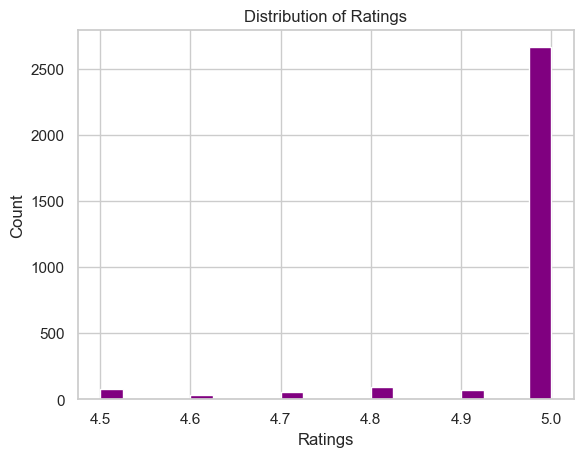

In [6]:
import matplotlib.pyplot as plt

plt.hist(df['Ratings'], bins=20,color='Purple')
plt.title("Distribution of Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

# 2. Menu Price Distributions

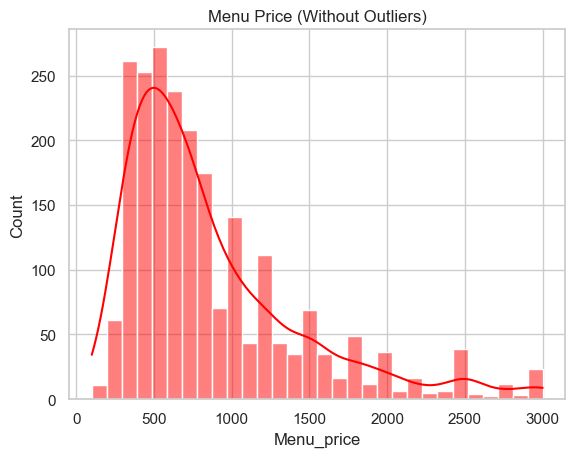

In [11]:
# Remove the extreme outliers
Q1 = df['Menu_price'].quantile(0.25)
Q3 = df['Menu_price'].quantile(0.75)
IQR = Q3 - Q1

filtered_df = df[(df['Menu_price'] >= Q1 - 1.5*IQR) & (df['Menu_price'] <= Q3 + 1.5*IQR)]

sns.histplot(filtered_df['Menu_price'], kde=True,color='Red')
plt.title("Menu Price (Without Outliers)")
plt.show()

# 3. Venue Type Count 

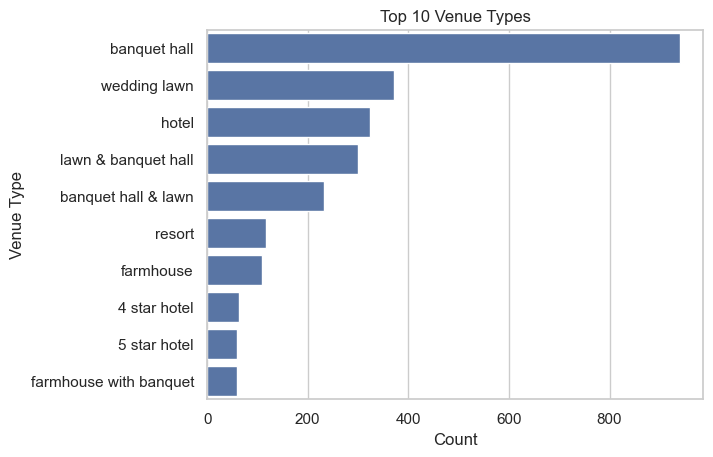

In [15]:
top_types = df['Type'].value_counts().head(10)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=top_types.values, y=top_types.index)
plt.title("Top 10 Venue Types")
plt.xlabel("Count")
plt.ylabel("Venue Type")
plt.show()

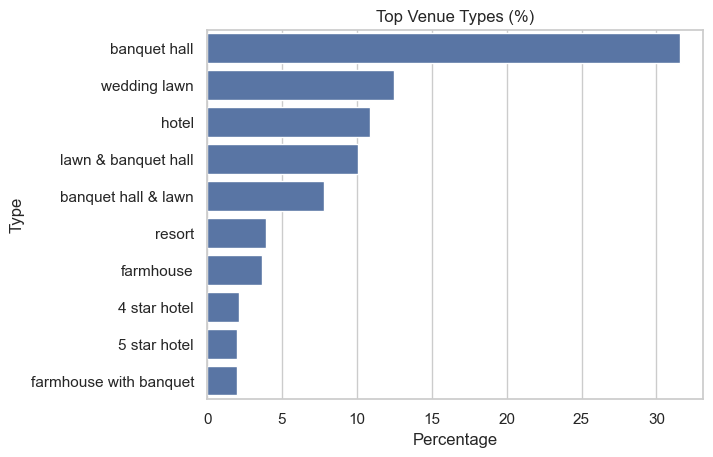

In [16]:
type_percent = (df['Type'].value_counts(normalize=True)*100).head(10)

sns.barplot(x=type_percent.values, y=type_percent.index)
plt.title("Top Venue Types (%)")
plt.xlabel("Percentage")
plt.show()

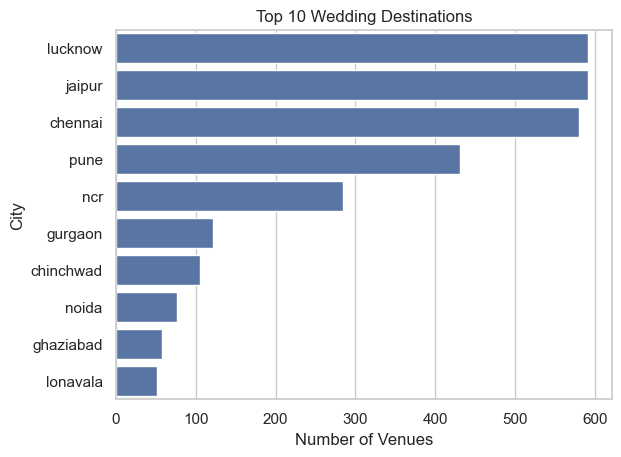

In [18]:
top_dest = df['Destination'].value_counts().head(10)

sns.barplot(x=top_dest.values, y=top_dest.index)
plt.title("Top 10 Wedding Destinations")
plt.xlabel("Number of Venues")
plt.ylabel("City")
plt.show()

# 2. Bivariate Analysis:

- Select 2 cols
- Understand type of relationship
    1. **Numerical - Numerical**<br>
        a. You can plot graphs like scatterplot(regression plots), 2D histplot, 2D KDEplots<br>
        b. Check correlation coefficent to check linear relationship
    2. **Numerical - Categorical** - create visualizations that compare the distribution of the numerical data across different categories of the categorical data.<br>
        a. You can plot graphs like barplot, boxplot, kdeplot ,violinplot even scatterplots<br>
    3. **Categorical - Categorical**<br>
        a. You can create cross-tabulations or contingency tables that show the distribution of values in one categorical column, grouped by the values in the other categorical column.<br>
        b. You can plots like heatmap, stacked barplots, treemaps

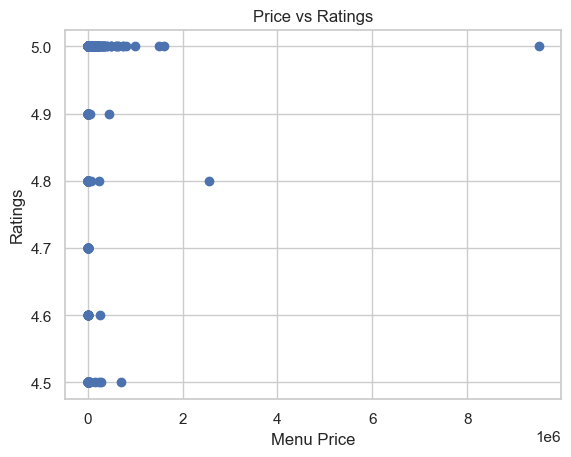

In [4]:
plt.scatter(df['Menu_price'], df['Ratings'])
plt.title("Price vs Ratings")
plt.xlabel("Menu Price")
plt.ylabel("Ratings")
plt.show()

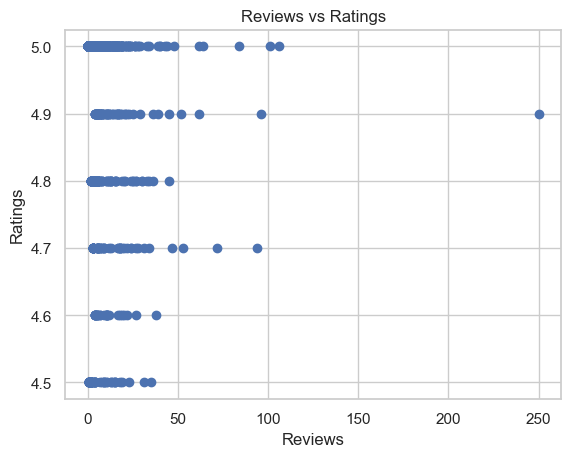

In [5]:
plt.scatter(df['Reviews'], df['Ratings'])
plt.title("Reviews vs Ratings")
plt.xlabel("Reviews")
plt.ylabel("Ratings")
plt.show()

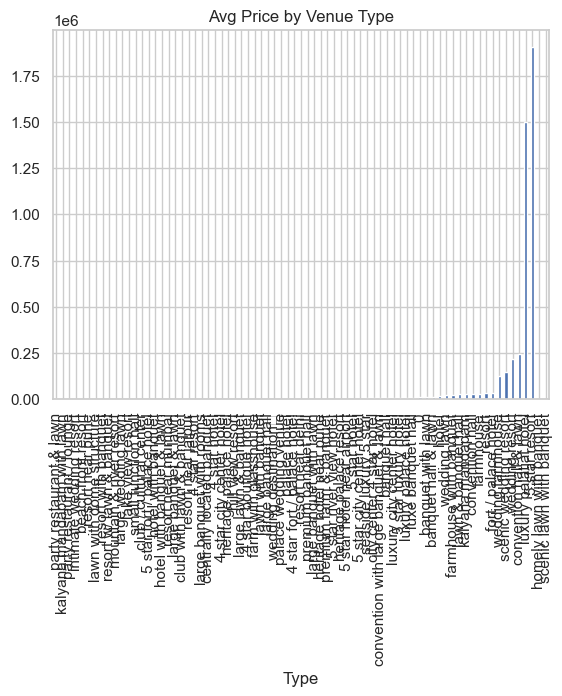

In [6]:
df.groupby('Type')['Menu_price'].mean().sort_values().plot(kind='bar')
plt.title("Avg Price by Venue Type")
plt.show()

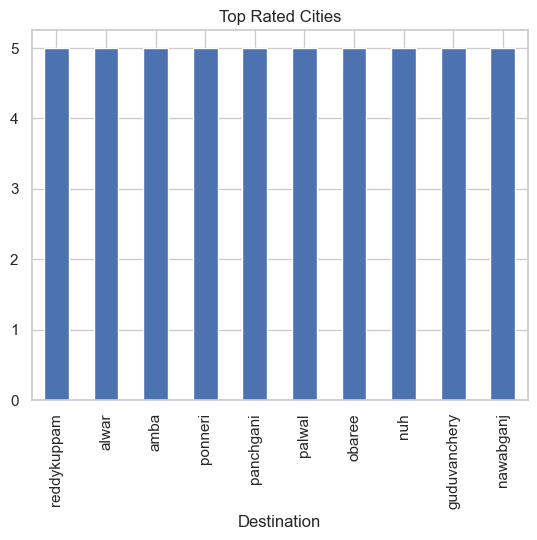

In [7]:
df.groupby('Destination')['Ratings'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Rated Cities")
plt.show()

# 3. Multivariate Analysis

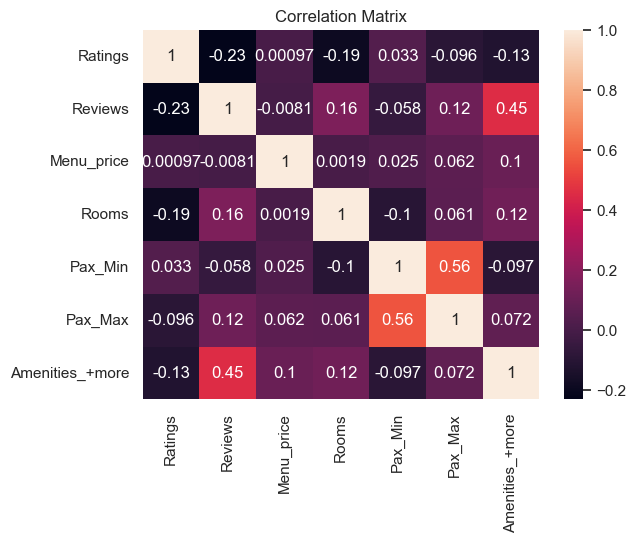

In [8]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

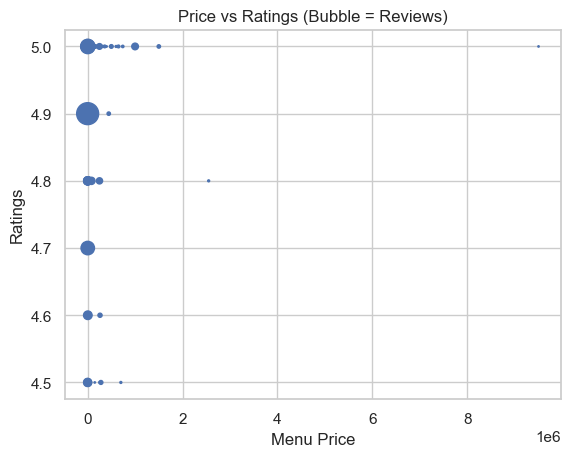

In [9]:
plt.scatter(df['Menu_price'], df['Ratings'], s=df['Reviews'])
plt.title("Price vs Ratings (Bubble = Reviews)")
plt.xlabel("Menu Price")
plt.ylabel("Ratings")
plt.show()